## Signal-to-Background Ratio (SBR) Sweep

Simulates localisation and spectral precision for ATTO 488, ATTO 565, and ATTO 647N
across a grid of signal levels (N photons) and SBR values (100 → 1).

When `SimulationConfig.sbr` is set, background_photons is computed per-frame as
`N_photons / SBR`, so SBR is held constant across the photon sweep rather than
using a fixed background level.

**Key result**: signal-limited (low N, high SBR) and background-limited (high N,
low SBR) conditions that share the same *effective* photon budget produce similar
distributions in the colour simplex — shown on ternary plots at the end.

In [1]:
import logging
logging.basicConfig(level=logging.INFO, format='%(name)s — %(levelname)s — %(message)s')

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import polars as pl
import pandas as pd
import os
import time
import glob
import types
from pathlib import Path
from scipy.spatial.distance import cdist
import xarray as xr
import sys

sys.path.append('../../..')
from src import IOFunctions, SpectralFunctions, MaskFunctions, sCMOSFunctions, PlottingBase
from src.Multicolour_Simulation_Functions import (
    FittingStrategy, SimulationConfig, MultiC_Sim_Funcs,
)

IO      = IOFunctions.IO_Functions()
S_F     = SpectralFunctions.Spectral_Funcs()
M_F     = MaskFunctions.Mask_Functions()
sCMOS   = sCMOSFunctions.sCMOS_Functions()
MSF     = MultiC_Sim_Funcs()
plotter = PlottingBase.PublicationPlotter()

smoothing_function = types.SimpleNamespace(
    args={'sigma': 1.5},
    extent=1.5,
    smoothing_function=sCMOS.gaussian_filter_stack,
    data_arg='image',
)

numexpr.utils — INFO — Note: NumExpr detected 20 cores but "NUMEXPR_MAX_THREADS" not set, so enforcing safe limit of 16.
numexpr.utils — INFO — NumExpr defaulting to 16 threads.
Constants — INFO — Logging to file: /home/jbeckwith/Documents/Chemistry/Lee/Code/Python/pyS3M/notebooks/figures/SI/../../../logs/Constants_20260701_111816.log


In [3]:
data_folder = '../../../Camera_Calibrations/Ximea_Camera/'
gain      = IO.read_tiff(os.path.join(data_folder, 'gain.tif'))
offset    = IO.read_tiff(os.path.join(data_folder, 'offset.tif'))
variance  = IO.read_tiff(os.path.join(data_folder, 'variance.tif'))
readnoise = float(np.median(IO.read_tiff(os.path.join(data_folder, 'readnoise.tif'))))
rqe       = IO.read_tiff(os.path.join(data_folder, 'rqe.tif'))
print(f'Camera calibration loaded — sensor: {gain.shape}, readnoise: {readnoise:.2f}')

Camera calibration loaded — sensor: (1544, 2064), readnoise: 2.34


In [4]:
# ── Bayer (RGGB) spectral setup ───────────────────────────────────────────────
R_base, G_base, B_base, wavelength = S_F.getpixelefficiency()
pixel_QYs = np.vstack([B_base, G_base, R_base])   # B=0, G=1, R=2
mosaic    = M_F.mosaic_unit                         # default BGGR Ximea pattern

pixel_order         = ['B', 'G', 'R']
pixel_order_indices = {'B': 0, 'G': 1, 'R': 2}

dyes    = ['ATTO 488', 'ATTO 565', 'ATTO 647N']
filters = []
NA          = 1.49
pixel_size  = 69.0
image_size  = 14    # seed size; test_simulation_method resizes via mosaic_unit

print(f'Wavelength: {wavelength[0]:.0f}–{wavelength[-1]:.0f} nm  ({len(wavelength)} pts)')
print(f'Mosaic unit: {mosaic}')

Wavelength: 400–999 nm  (600 pts)
Mosaic unit: [['B' 'G']
 ['G' 'R']]


In [5]:
# ── Save folder + sweep parameters ────────────────────────────────────────────
save_folder = Path('/home/jbeckwith/Documents/Chemistry/Lee/Data/Simulation/20260630_SBR')
save_folder.mkdir(parents=True, exist_ok=True)
print(f'Save folder: {save_folder}')

n_photon_space = np.unique(
    np.around(np.logspace(np.log10(500), np.log10(50000), 200) / 5) * 5
)
sbr_space = np.geomspace(1, 100, 25)[::-1]

config_base = SimulationConfig(
    n_bootstrap=10000,
    background_photons=5.0,   # fallback only; overridden by sbr
    NA=NA,
    pixel_size=pixel_size,
    save_raw_results=True,
    subtractx0y0=False,
    saverawimages=False,
    verbose=False,
    use_stochastic_photons=True,
    n_unit_cells=7,
)

print(f'Photon levels : {len(n_photon_space)}  ({n_photon_space[0]:.0f}–{n_photon_space[-1]:.0f})')
print(f'SBR values    : {sbr_space}')
print(f'Total runs    : {len(dyes)} dyes × {len(sbr_space)} SBRs = {len(dyes)*len(sbr_space)}')

Save folder: /home/jbeckwith/Documents/Chemistry/Lee/Data/Simulation/20260630_SBR
Photon levels : 200  (500–50000)
SBR values    : [ 100.           82.54041853   68.12920691   56.23413252   46.41588834
   38.3118685    31.6227766    26.10157216   21.5443469    17.7827941
   14.67799268   12.11527659   10.            8.25404185    6.81292069
    5.62341325    4.64158883    3.83118685    3.16227766    2.61015722
    2.15443469    1.77827941    1.46779927    1.21152766    1.        ]
Total runs    : 3 dyes × 25 SBRs = 75


In [6]:
# ── Camera parameters (mosaic_unit triggers auto-resize in test_simulation_method) ──
camera_params_dict = {
    'gain':               np.full((image_size, image_size), np.median(gain)),
    'offset':             np.full((image_size, image_size), np.median(offset)),
    'variance':           np.full((image_size, image_size), np.median(variance)),
    'readnoise':          readnoise,
    'rqe':                np.full((image_size, image_size), np.median(rqe)),
    'masks':              M_F.get_masks(size_x=image_size, size_y=image_size),
    'pixel_QYs':          pixel_QYs,
    'pixel_order':        pixel_order,
    'pixel_order_indices': pixel_order_indices,
    'mosaic_unit':        mosaic,
}
print(f'Camera params ready — base image size: {image_size}×{image_size} px')

Camera params ready — base image size: 14×14 px


## Simulation

For each dye × SBR, `test_simulation_method` sweeps `n_photon_space`.
Background photons for each frame = `N_photons / SBR` (via `SimulationConfig.sbr`).

In [7]:
# ── Run SBR sweep ──────────────────────────────────────────────────────────────
n_total = len(dyes) * len(sbr_space)
i_run   = 0
t_start = time.time()

for dye in dyes:
    for sbr in sbr_space:
        i_run += 1
        flag = f'sbr{sbr:.2f}_'.replace('.', 'p')

        config = SimulationConfig(
            n_bootstrap=config_base.n_bootstrap,
            background_photons=config_base.background_photons,
            NA=config_base.NA,
            pixel_size=config_base.pixel_size,
            save_raw_results=config_base.save_raw_results,
            subtractx0y0=config_base.subtractx0y0,
            saverawimages=config_base.saverawimages,
            verbose=config_base.verbose,
            use_stochastic_photons=config_base.use_stochastic_photons,
            n_unit_cells=config_base.n_unit_cells,
            sbr=sbr,
        )

        print(f'[{i_run:2d}/{n_total}]  {dye}  SBR={sbr:.0f}', end='  ', flush=True)

        MSF.test_simulation_method(
            dye=dye,
            filters=filters,
            wavelength=wavelength,
            camera_parameters=camera_params_dict,
            save_folder=str(save_folder),
            n_photon_space=n_photon_space,
            smoothing_function=smoothing_function,
            strategy=FittingStrategy.STANDARD,
            starting_flag=flag,
            config=config,
            overwrite=False,
        )

        elapsed = (time.time() - t_start) / 60
        rate    = i_run / elapsed if elapsed > 0 else 0
        eta     = (n_total - i_run) / rate if rate > 0 else 0
        print(f'done  ({elapsed:.1f} min, ETA {eta:.1f} min)')

print(f'\nSweep complete in {(time.time()-t_start)/60:.1f} min.')

simulation.multicolour — INFO — 
Completed analysis of 200 photon flux values    Total time: 38.034 min
simulation.multicolour — INFO — Simulation completed for strategy standard


done  (38.0 min, ETA 2814.8 min)


simulation.multicolour — INFO — 
Completed analysis of 200 photon flux values    Total time: 37.151 min
simulation.multicolour — INFO — Simulation completed for strategy standard


done  (75.2 min, ETA 2744.4 min)


simulation.multicolour — INFO — 
Completed analysis of 200 photon flux values    Total time: 37.428 min
simulation.multicolour — INFO — Simulation completed for strategy standard


...

done  (2744.9 min, ETA 75.2 min)


simulation.multicolour — INFO — 
Completed analysis of 200 photon flux values    Total time: 37.568 min
simulation.multicolour — INFO — Simulation completed for strategy standard


done  (2782.4 min, ETA 37.6 min)


simulation.multicolour — INFO — 
Completed analysis of 200 photon flux values    Total time: 38.073 min
simulation.multicolour — INFO — Simulation completed for strategy standard


done  (2820.5 min, ETA 0.0 min)

Sweep complete in 2820.5 min.


## Analysis

Load raw HDF5 results and ground-truth CSVs; compute σ_xy (nm) and σ_colour per
(dye, SBR, N_photons) cell.

In [8]:
# ── Build xarray: [dye, sbr, n_photons, metric] ───────────────────────────────
metrics    = ['sigma_xy', 'sigma_colour']
a_cols     = [f'A_{l}' for l in pixel_order]
n_unit     = config_base.n_unit_cells

SBR_XR = xr.DataArray(
    data=np.full(
        [len(dyes), len(sbr_space), len(n_photon_space), len(metrics)], np.nan
    ),
    coords={
        'dye':       dyes,
        'sbr':       sbr_space,
        'n_photons': n_photon_space,
        'metric':    metrics,
    },
    dims=['dye', 'sbr', 'n_photons', 'metric'],
)

missing = []
for i_d, dye in enumerate(dyes):
    dye_str = dye.replace('/', '-')
    for i_s, sbr in enumerate(sbr_space):
        flag = f'sbr{sbr:.2f}_'.replace('.', 'p')

        h5_path = save_folder / f'{flag}LM_method_{dye_str}_rawresults.h5'
        gt_path = sorted(glob.glob(str(save_folder / f'{flag}*{dye_str}*groundtruth*.csv')))
        ip_path = sorted(glob.glob(str(save_folder / f'{flag}*{dye_str}*input_parameters*.csv')))

        if not h5_path.exists() or not gt_path or not ip_path:
            missing.append((dye, sbr))
            continue

        gt    = pd.read_csv(gt_path[0])
        gt_px = np.vstack([gt['x0'].to_numpy() / pixel_size,
                           gt['y0'].to_numpy() / pixel_size]).T

        ip_row      = pd.read_csv(ip_path[0]).to_numpy()[0]
        colour_raw  = ip_row[-3:]          # B, G, R fractions from input_parameters
        colour_true = np.expand_dims(colour_raw / colour_raw.sum(), 0)

        df_raw = pd.read_hdf(str(h5_path), key='data')

        for k in range(len(n_photon_space)):
            sub  = df_raw[df_raw['photon_level'] == k]
            filt = (
                (sub['xc'].to_numpy() > 0) &
                (sub['yc'].to_numpy() > 0) &
                (sub['s_x'].to_numpy() > 0) &
                (sub['s_y'].to_numpy() > 0) &
                (sub['xc'].to_numpy() < n_unit * mosaic.shape[0]) &
                (sub['yc'].to_numpy() < n_unit * mosaic.shape[1])
            )
            if filt.sum() < 5:
                continue

            ex = (sub['xc'].to_numpy()[filt] - gt_px[filt, 0]) * pixel_size
            ey = (sub['yc'].to_numpy()[filt] - gt_px[filt, 1]) * pixel_size
            SBR_XR[i_d, i_s, k, 0] = np.sqrt(
                (np.nanstd(ex) ** 2 + np.nanstd(ey) ** 2) / 2
            )

            colours = np.vstack([sub[c].to_numpy()[filt] for c in a_cols]).T
            SBR_XR[i_d, i_s, k, 1] = float(np.nanstd(cdist(colours, colour_true)))

if missing:
    print(f'Missing: {missing}')
SBR_XR.to_netcdf(str(save_folder / 'SBR_XR.nc'))
print(f'DataArray shape: {SBR_XR.shape}  dims: {list(SBR_XR.dims)}')
print(f'σ_xy  range: {float(np.nanmin(SBR_XR.sel(metric="sigma_xy"))):.1f}–'
      f'{float(np.nanmax(SBR_XR.sel(metric="sigma_xy"))):.1f} nm')
print(f'σ_col range: {float(np.nanmin(SBR_XR.sel(metric="sigma_colour"))):.4f}–'
      f'{float(np.nanmax(SBR_XR.sel(metric="sigma_colour"))):.4f}')

DataArray shape: (3, 25, 200, 2)  dims: ['dye', 'sbr', 'n_photons', 'metric']
σ_xy  range: 0.8–88.7 nm
σ_col range: 0.0044–0.2374


## Precision Surfaces

For each dye, plot a 2D heatmap with N_photons (log x) × SBR (log y)
and colour = precision.  Rows: σ_xy / σ_colour.  Columns: dyes.

In [9]:
# ── Load (re-run analysis without re-simulating) ──────────────────────────────
SBR_XR = xr.open_dataarray(str(save_folder / 'SBR_XR.nc'))
fs = plotter.config.font_size

src.PlottingBase — INFO — Plot saved to: /home/jbeckwith/Documents/Chemistry/Lee/Data/Simulation/20260630_SBR/sbr_surface_sigma_xy.svg


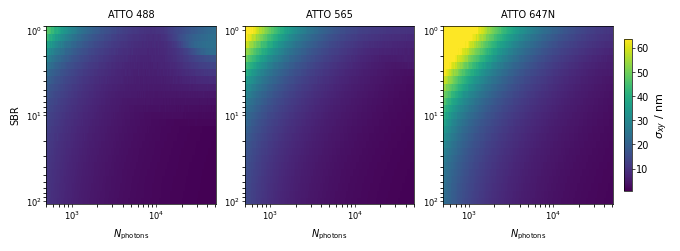

Saved sbr_surface_sigma_xy.svg


src.PlottingBase — INFO — Plot saved to: /home/jbeckwith/Documents/Chemistry/Lee/Data/Simulation/20260630_SBR/sbr_surface_sigma_colour.svg


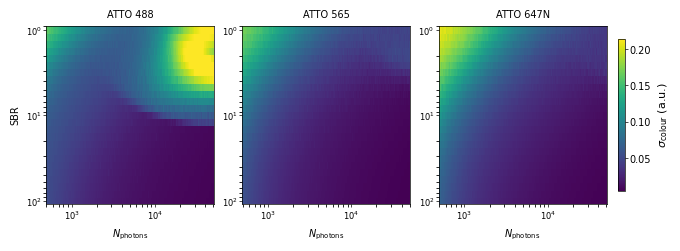

Saved sbr_surface_sigma_colour.svg


In [10]:
# ── Surface plots: rows = metric, cols = dye ──────────────────────────────────
metric_info = [
    ('sigma_xy',     r'$\sigma_{xy}$ / nm',          'viridis'),
    ('sigma_colour', r'$\sigma_{\rm colour}$ (a.u.)', 'viridis'),
]

for metric, cbar_lbl, cmap in metric_info:
    data_all = SBR_XR.sel(metric=metric).values   # (n_dye, n_sbr, n_ph)
    vmin = float(np.nanmin(data_all))
    vmax = float(np.nanpercentile(data_all, 99))
    norm = mcolors.Normalize(vmin=vmin, vmax=vmax)

    fig, axs = plt.subplots(
        nrows=1, ncols=len(dyes),
        figsize=(6.69, 2.4), squeeze=False,
    )
    for i_d, dye in enumerate(dyes):
        ax = axs[0, i_d]
        # Z shape: (n_sbr, n_ph); pcolormesh expects (Y, X)
        Z = SBR_XR.isel(dye=i_d).sel(metric=metric).values   # (n_sbr, n_ph)
        ax.pcolormesh(
            SBR_XR.coords['n_photons'].values,
            SBR_XR.coords['sbr'].values,
            Z,
            cmap=cmap, shading='auto', norm=norm,
        )
        ax.set_xscale('log')
        ax.set_yscale('log')
        ax.set_xlabel(r'$N_{\rm photons}$', fontsize=fs)
        ax.set_ylabel('SBR' if i_d == 0 else '', fontsize=fs)
        ax.set_title(dye, fontsize=fs)
        ax.tick_params(labelsize=fs - 1)
        # Invert y so high SBR is at top (best conditions)
        ax.invert_yaxis()

    fig.colorbar(
        plt.cm.ScalarMappable(norm=norm, cmap=cmap),
        ax=axs,
        label=cbar_lbl,
        shrink=0.85, aspect=20, pad=0.02,
    )
    fname = f'sbr_surface_{metric}.svg'
    plotter.save_or_show(fig, save_path=str(save_folder / fname), show=True)
    print(f'Saved {fname}')

## Ternary Plots — Case Studies

Compare three regimes that nominally differ in *kind* of limitation:

| Case | N photons | SBR | Limitation |
|------|-----------|-----|------------|
| A    | ~5 000    | 100 | — (reference) |
| B    | ~500      | 100 | signal-limited |
| C    | ~5 000    |   1 | background-limited |

If the spread in the colour simplex is similar for B and C, the two regimes
are physically equivalent for spectral discrimination purposes.

In [11]:
# ── Ternary helper functions ───────────────────────────────────────────────────
_H = np.sqrt(3) / 2

def _ternary_xy(b, g, r):
    """(B, G, R) fractions → 2-D Cartesian.  B=left, R=right, G=top."""
    return r + g / 2, g * _H

def _setup_ternary(ax, fontsize=7):
    """Draw triangle outline, gridlines at 1/4 intervals, and vertex labels."""
    # Triangle
    tri = np.array([[0, 0], [1, 0], [0.5, _H], [0, 0]])
    ax.plot(tri[:, 0], tri[:, 1], 'k-', lw=0.8)
    # Grid at 0.25, 0.5, 0.75
    for f in [0.25, 0.5, 0.75]:
        # g = f  (horizontal, parallel to BR)
        ax.plot([f / 2, 1 - f / 2], [f * _H, f * _H], 'k:', lw=0.3, alpha=0.4)
        # r = f  (parallel to BG, lower-left to upper-right)
        ax.plot([f, 0.5 + f / 2], [0, (1 - f) * _H], 'k:', lw=0.3, alpha=0.4)
        # b = f  (parallel to GR, lower-right to upper-left)
        ax.plot([(1 - f) / 2, 1 - f], [(1 - f) * _H, 0], 'k:', lw=0.3, alpha=0.4)
    ax.set_aspect('equal')
    ax.set_xlim(-0.18, 1.18)
    ax.set_ylim(-0.14, _H + 0.14)
    ax.axis('off')
    ax.text(-0.10, -0.09, 'B', ha='center', va='center', fontsize=fontsize, fontweight='bold')
    ax.text( 1.10, -0.09, 'R', ha='center', va='center', fontsize=fontsize, fontweight='bold')
    ax.text( 0.50,  _H + 0.09, 'G', ha='center', va='center', fontsize=fontsize, fontweight='bold')

print('Ternary helper functions defined.')

Ternary helper functions defined.


/tmp/ipykernel_3374654/4006099914.py:79: UserWarning: This figure was using a layout engine that is incompatible with subplots_adjust and/or tight_layout; not calling subplots_adjust.
  fig.subplots_adjust(wspace=0.1, hspace=0.15)
src.PlottingBase — INFO — Plot saved to: /home/jbeckwith/Documents/Chemistry/Lee/Data/Simulation/20260630_SBR/sbr_ternary_cases.svg


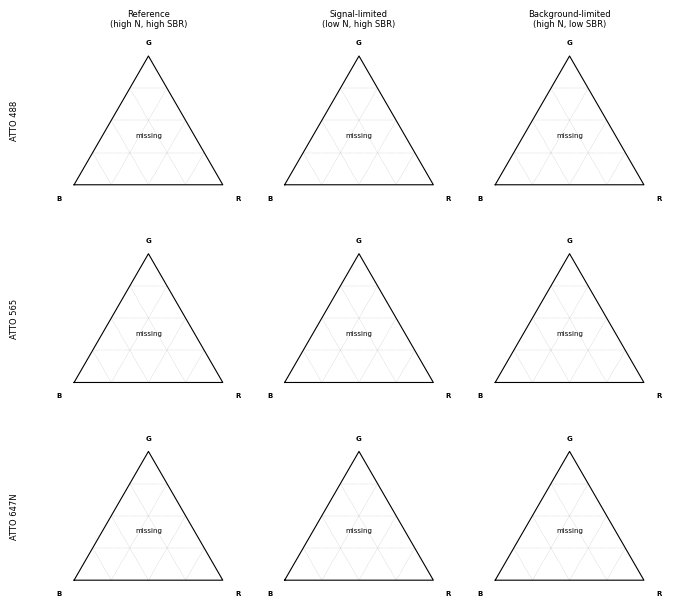

Ternary case study figure saved.


In [12]:
# ── Define case-study conditions ───────────────────────────────────────────────
cases = [
    ('Reference\n(high N, high SBR)', 5000, 100.0, '#2196F3'),
    ('Signal-limited\n(low N, high SBR)',  500, 100.0, '#FF9800'),
    ('Background-limited\n(high N, low SBR)', 5000,   1.0, '#E91E63'),
]
n_subsample = 3000   # max points per ternary panel

# ── Build grid: rows = dyes, cols = cases ─────────────────────────────────────
n_rows, n_cols = len(dyes), len(cases)
fig, axs = plotter.two_column_plot(
    nrows=n_rows, ncols=n_cols,
    height=n_rows * (6.69 / n_cols) * _H + 0.3,
)

for i_d, dye in enumerate(dyes):
    dye_str = dye.replace('/', '-')

    # True colour (B, G, R fractions) from any input_parameters file for this dye
    ip_any = sorted(glob.glob(str(save_folder / f'sbr100_*{dye_str}*input_parameters*.csv')))
    if ip_any:
        ip_row      = pd.read_csv(ip_any[0]).to_numpy()[0]
        colour_true = ip_row[-3:] / ip_row[-3:].sum()   # (B, G, R)
    else:
        colour_true = None

    for i_c, (case_label, n_ph_target, sbr_target, colour) in enumerate(cases):
        ax = axs[i_d, i_c]
        _setup_ternary(ax, fontsize=fs - 2)

        flag    = f'sbr{sbr_target:.0f}_'
        h5_path = save_folder / f'{flag}LM_method_{dye_str}_rawresults.h5'

        if not h5_path.exists():
            ax.text(0.5, 0.4, 'missing', ha='center', fontsize=fs-2,
                    transform=ax.transAxes)
        else:
            df_raw = pd.read_hdf(str(h5_path), key='data')

            # Find photon-level index closest to target
            k_closest = int(np.argmin(np.abs(n_photon_space - n_ph_target)))
            sub = df_raw[df_raw['photon_level'] == k_closest]
            filt = (
                (sub['s_x'].to_numpy() > 0) &
                (sub['s_y'].to_numpy() > 0) &
                (sub['xc'].to_numpy() > 0) &
                (sub['yc'].to_numpy() > 0)
            )
            sub_f = sub[filt]
            n_pts = min(len(sub_f), n_subsample)
            idx   = np.random.choice(len(sub_f), n_pts, replace=False)

            b_vals = sub_f['A_B'].to_numpy()[idx]
            g_vals = sub_f['A_G'].to_numpy()[idx]
            r_vals = sub_f['A_R'].to_numpy()[idx]

            x_pts, y_pts = _ternary_xy(b_vals, g_vals, r_vals)
            ax.scatter(x_pts, y_pts, s=0.8, alpha=0.25, color=colour, rasterized=True)

            # True colour marker
            if colour_true is not None:
                xc, yc = _ternary_xy(*colour_true)
                ax.scatter([xc], [yc], s=30, marker='+', color='black', linewidths=0.8,
                           zorder=5)

            n_actual = n_photon_space[k_closest]
            ax.text(0.5, -0.07,
                    f'N≈{n_actual:.0f}, SBR={sbr_target:.0f}',
                    ha='center', fontsize=fs - 3,
                    transform=ax.transAxes)

        if i_d == 0:
            ax.set_title(case_label, fontsize=fs - 1)
        if i_c == 0:
            ax.text(-0.14, 0.5, dye,
                    transform=ax.transAxes,
                    fontsize=fs - 1, va='center', ha='right', rotation=90)

fig.subplots_adjust(wspace=0.1, hspace=0.15)
plotter.save_or_show(
    fig, save_path=str(save_folder / 'sbr_ternary_cases.svg'), show=True
)
print('Ternary case study figure saved.')

## Precision along the SBR diagonal

Extract σ_xy and σ_colour along the diagonal where `N_photons × SBR = constant`
(i.e. fixed total detected photons but traded between signal and background).
Points along this diagonal should show similar precision, confirming the equivalence.

/tmp/ipykernel_3374654/4036458716.py:41: UserWarning: The figure layout has changed to tight
  fig.tight_layout(pad=0.4)
src.PlottingBase — INFO — Plot saved to: /home/jbeckwith/Documents/Chemistry/Lee/Data/Simulation/20260630_SBR/sbr_effective_photons_collapse.svg


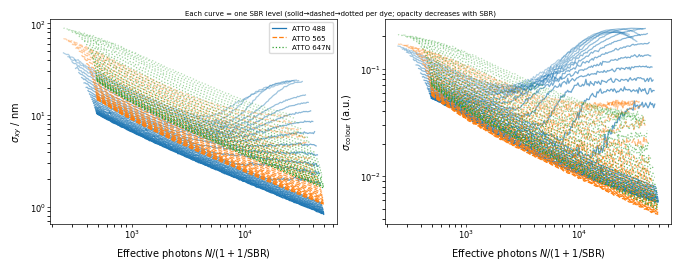

Effective-photon collapse figure saved.


In [13]:
# ── Iso-effective-photon curves ────────────────────────────────────────────────
# For each (N, SBR) pair, the effective detected photons contributing to
# localisation precision scales roughly as N/(1 + 1/SBR).  Plot precision
# vs this effective N so that signal-limited and background-limited cases
# collapse onto a single curve.

def effective_photons(n, sbr):
    """Approximation: photon-limited Fisher information with uniform background."""
    return n / (1 + 1 / sbr)

N_grid, SBR_grid = np.meshgrid(n_photon_space, sbr_space)   # (n_sbr, n_ph)
N_eff = effective_photons(N_grid, SBR_grid)

fs = plotter.config.font_size
fig, axs = plt.subplots(1, 2, figsize=(6.69, 2.6), squeeze=True)

for ax, metric, ylabel in [
    (axs[0], 'sigma_xy',     r'$\sigma_{xy}$ / nm'),
    (axs[1], 'sigma_colour', r'$\sigma_{\rm colour}$ (a.u.)'),
]:
    for i_d, (dye, ls) in enumerate(zip(dyes, ['-', '--', ':'])):
        for i_s, (sbr, alpha) in enumerate(zip(sbr_space, np.linspace(1.0, 0.35, len(sbr_space)))):
            y = SBR_XR.isel(dye=i_d, sbr=i_s).sel(metric=metric).values
            x = N_eff[i_s, :]
            valid = ~np.isnan(y)
            label = dye if i_s == 0 else None
            ax.plot(x[valid], y[valid], ls=ls, lw=0.9,
                    color=f'C{i_d}', alpha=alpha, label=label)

    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xlabel(r'Effective photons $N/(1+1/\mathrm{SBR})$', fontsize=fs)
    ax.set_ylabel(ylabel, fontsize=fs)
    ax.tick_params(labelsize=fs - 1)

axs[0].legend(fontsize=fs - 2, framealpha=0.7)
fig.suptitle(
    'Each curve = one SBR level (solid→dashed→dotted per dye; opacity decreases with SBR)',
    fontsize=fs - 2,
)
fig.tight_layout(pad=0.4)
plotter.save_or_show(
    fig, save_path=str(save_folder / 'sbr_effective_photons_collapse.svg'), show=True
)
print('Effective-photon collapse figure saved.')